In [67]:
"""Accuracy vs. transition budget (base style) for each model, one line per dataset."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [68]:
# --- configuration ---

OUTPUT_DIR = Path("../output")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# models to compare: display name → model key (used to build onepass/twopass filenames)
MODELS: dict[str, str] = {
    "Qwen3-8B": "qwen3-8b",
    "Qwen3-14B": "qwen3-14b",
    "Qwen3-32B": "qwen3-32b",
    "OLMo3-7B": "olmo-3-7b",
    "Llama-R1-8B": "llama-r1-8b",
    "OpenReason-7B": "or-7b",
    "CodeReason-7B": "ocr-7b",
}

# code benchmarks only: display label → key prefix in results files
DATASETS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "CodeContests": "code/code_contests_greedy",
    "CRUX-Input": "crux/cruxeval_i_greedy",
    "CRUX-Output": "crux/cruxeval_o_greedy",
}

# total token budget used in all runs
MAX_TOKENS = 32768

# human-readable labels for token budget sizes on the x-axis
BUDGET_LABELS: dict[int, str] = {
    0: "0",
    4096: "4K",
    8192: "8K",
    12288: "12K",
    16384: "16K",
    20480: "20K",
    24576: "24K",
    28762: "28K",
}

# shared palette — matches the violin plots in notebook 02
_P = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
    "#00BCD4",  # cyan
    "#A65628",  # brown
    "#F781BF",  # pink
    "#FF4081",  # deep pink
]

# colour groups by model family — must match SERIES colours in notebooks 02 and 03:
#   qwen3 models → blue / teal / cyan (similar, distinct)
#   or / ocr     → purple / pink
#   olmo / llama → orange / brown
MODEL_COLOURS: dict[str, str] = {
    "Qwen3-8B": "#377EB8",
    "Qwen3-14B": "#009688",
    "Qwen3-32B": "#00BCD4",
    "OLMo3-7B": "#FF7F00",
    "Llama-R1-8B": "#A65628",
    "OpenReason-7B": "#984EA3",
    "CodeReason-7B": "#F781BF",
}

# set to True to shade the 95% CI band around each transition line
SHOW_CI: bool = False

In [69]:
def load_model_data(
    model_key: str,
) -> dict[str, dict]:
    """Load twopass accuracy data and onepass/nothink baselines for all available datasets.

    Reads {model_key}_twopass.json for transition budget points,
    {model_key}_onepass.json for the unconstrained baseline, and
    {model_key}_nothink.json for the zero-budget (no reasoning) point.
    For each dataset prefix the function collects every twopass entry (keys
    ending in _th{budget}_base) and the baseline entry (key ending in _onepass).
    CI bounds (pass_at_1_ci) are included where available. When nothink data
    exists, budget 0 is prepended to the budgets list so it appears as the
    leftmost point on each model's transition line.

    Returns a dict: dataset_label → {
        "budgets": [...], "accuracies": [...],
        "ci_lo": [...], "ci_hi": [...],
        "baseline": float | None,
        "baseline_ci": [float, float] | None,
    }
    """
    twopass_path = OUTPUT_DIR / f"{model_key}_twopass.json"
    onepass_path = OUTPUT_DIR / f"{model_key}_onepass.json"
    nothink_path = OUTPUT_DIR / f"{model_key}_nothink.json"

    twopass = json.load(open(twopass_path)) if twopass_path.exists() else {}
    onepass = json.load(open(onepass_path)) if onepass_path.exists() else {}
    nothink = json.load(open(nothink_path)) if nothink_path.exists() else {}

    data: dict[str, dict] = {}
    for label, prefix in DATASETS.items():
        # twopass keys: "{prefix}_mx{MAX_TOKENS}_th{budget}_base"
        prefix_mx = f"{prefix}_mx{MAX_TOKENS}_"
        th_keys = [
            k
            for k in twopass
            if k.startswith(prefix_mx) and k.endswith("_base") and "_th" in k
        ]
        if not th_keys:
            continue

        # use a dict to deduplicate entries with the same budget value, then sort
        budget_dict: dict[int, tuple[int, float, float, float]] = {}
        for key in th_keys:
            # key format: {prefix}_mx{MAX_TOKENS}_th{budget}_base
            budget = int(key.split("_th")[1].split("_base")[0])
            entry = twopass[key]
            acc = entry["pass_at_1"]
            ci = entry.get("pass_at_1_ci", [acc, acc])
            budget_dict[budget] = (budget, acc, ci[0], ci[1])
        budget_acc = sorted(budget_dict.values(), key=lambda x: x[0])

        # onepass baseline: "{prefix}_mx{MAX_TOKENS}_onepass"
        baseline_key = f"{prefix}_mx{MAX_TOKENS}_onepass"
        baseline_entry = onepass.get(baseline_key)
        baseline = baseline_entry["pass_at_1"] if baseline_entry else None
        baseline_ci = baseline_entry.get("pass_at_1_ci") if baseline_entry else None

        # nothink: budget 0 (no reasoning at all), greedy config — same prefix as twopass
        # when present, prepend as the leftmost point (budget=0) on the transition line
        nothink_key = f"{prefix}_mx{MAX_TOKENS}_nothink"
        nothink_entry = nothink.get(nothink_key)
        if nothink_entry is not None:
            nothink_acc = nothink_entry["pass_at_1"]
            nothink_ci = nothink_entry.get("pass_at_1_ci", [nothink_acc, nothink_acc])
            # prepend as the leftmost point (budget=0) on the transition line
            budget_acc.insert(0, (0, nothink_acc, nothink_ci[0], nothink_ci[1]))

        data[label] = {
            "budgets": [b for b, _, _, _ in budget_acc],
            "accuracies": [a for _, a, _, _ in budget_acc],
            "ci_lo": [lo for _, _, lo, _ in budget_acc],
            "ci_hi": [hi for _, _, _, hi in budget_acc],
            "baseline": baseline,
            "baseline_ci": baseline_ci,
        }

    return data

In [70]:
# dark grey used for shared legend annotation entries
_DARK_GREY = "#444444"

# inches reserved at the bottom of the figure for the 2-row legend
_LEGEND_HEIGHT_IN = 0.65

# vertical offset (figure fraction) of the top legend row (models) above the
# bottom row (Baseline / Peak pass@1), which sits at bbox_to_anchor y=0
_LEGEND_ROW_GAP = 0.022


def _legend_extras() -> tuple[list, list[str]]:
    """Return proxy handles and labels for the Baseline and Peak legend entries.

    Returns two Line2D proxy artists (dark grey dashed line and dark grey star)
    used to annotate every shared legend identically.
    """
    baseline = Line2D([], [], color=_DARK_GREY, linewidth=1.2, linestyle="--")
    peak = Line2D([], [], color=_DARK_GREY, marker="*", markersize=10, linewidth=0)
    return [baseline, peak], ["Baseline", "Peak pass@1"]


def _apply_legend_italic(leg) -> None:
    """Set fontstyle=italic on any legend text entry containing 'pass@1'.

    Uses system-font italic (via fontstyle) rather than mathtext, so all
    characters including '@' and digits are properly italicised.
    """
    for text in leg.get_texts():
        if "pass@1" in text.get_text():
            text.set_fontstyle("italic")


def plot_all_models_per_benchmark(
    all_model_data: dict[str, dict[str, dict]],
    save_path: Path,
    n_cols: int = 2,
    left_ylabel_only: bool = False,
) -> None:
    """Plot all models together on one figure, one subplot per benchmark.

    Subplots are arranged in ceil(n_datasets / n_cols) rows × n_cols columns.
    Each subplot shows one line per model (accuracy vs. transition budget). A star
    marker highlights the peak accuracy budget for each line. Where a baseline exists
    it is drawn as a dashed horizontal line in the same colour. CI shading is
    controlled by SHOW_CI. Two stacked, independently centred legend rows are placed
    below: models on top, Baseline / Peak pass@1 on the bottom. The total figure
    width is fixed at 13 inches regardless of n_cols; row height is fixed at 4.0
    inches per row, plus extra height reserved for the 2-row legend. When
    left_ylabel_only is True, the y-axis label is only drawn on the leftmost column
    of subplots. Saves the combined figure as a PNG.
    """
    n_datasets = len(DATASETS)
    n_rows = (n_datasets + n_cols - 1) // n_cols  # ceiling division

    fig_height = 3.8 * n_rows + _LEGEND_HEIGHT_IN

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(13, fig_height),
    )

    # flatten so we can index by position regardless of n_rows
    flat_axes = axes.flatten()

    # collect legend handles once (same across all subplots)
    legend_handles: list = []
    legend_labels: list[str] = []

    for ax_idx, (ax, dataset_label) in enumerate(zip(flat_axes, DATASETS)):
        # track all y-values to set a zoomed y-axis range after drawing
        all_vals: list[float] = []

        for model_name, model_data in all_model_data.items():
            if dataset_label not in model_data:
                continue

            ds_data = model_data[dataset_label]
            colour = MODEL_COLOURS[model_name]
            budgets = ds_data["budgets"]
            accuracies = [a * 100 for a in ds_data["accuracies"]]
            all_vals.extend(accuracies)

            if SHOW_CI:
                ci_lo = [v * 100 for v in ds_data["ci_lo"]]
                ci_hi = [v * 100 for v in ds_data["ci_hi"]]
                all_vals.extend(ci_lo + ci_hi)
                ax.fill_between(
                    budgets,
                    ci_lo,
                    ci_hi,
                    color=colour,
                    alpha=0.15,
                    linewidth=0,
                )

            # main line with circular markers at each budget point
            (line,) = ax.plot(
                budgets,
                accuracies,
                marker="o",
                markersize=4,
                linewidth=2,
                color=colour,
                label=model_name,
            )

            # star at the peak accuracy budget
            peak_idx = accuracies.index(max(accuracies))
            ax.plot(
                budgets[peak_idx],
                accuracies[peak_idx],
                marker="*",
                markersize=12,
                color=colour,
                zorder=5,
            )

            # collect legend entries once (from the first subplot only)
            if ax_idx == 0:
                legend_handles.append(line)
                legend_labels.append(model_name)

            # dashed horizontal baseline in the same model colour where available
            if ds_data["baseline"] is not None:
                baseline_pct = ds_data["baseline"] * 100
                all_vals.append(baseline_pct)

                if SHOW_CI and ds_data["baseline_ci"] is not None:
                    lo, hi = [v * 100 for v in ds_data["baseline_ci"]]
                    ax.axhspan(lo, hi, color=colour, alpha=0.08, linewidth=0)
                    all_vals.extend([lo, hi])

                ax.axhline(
                    y=baseline_pct,
                    color=colour,
                    linewidth=1.2,
                    linestyle="--",
                    alpha=0.7,
                )

        ax.set_title(dataset_label, fontsize=13, fontweight="bold")
        ax.set_xlabel("Transition budget (tokens)", fontsize=11)

        # only label the y-axis on leftmost subplots when left_ylabel_only is set
        if not left_ylabel_only or ax_idx % n_cols == 0:
            # fontstyle='italic' uses system font, so '@' and '1' are properly italic
            ax.set_ylabel("pass@1 (%)", fontstyle="italic", fontsize=11)

        # x-ticks: all budget values found across every model for this benchmark
        all_budgets = sorted(
            {
                b
                for model_data in all_model_data.values()
                if dataset_label in model_data
                for b in model_data[dataset_label]["budgets"]
            }
        )
        ax.set_xticks(all_budgets)
        ax.set_xticklabels(
            [BUDGET_LABELS.get(b, str(b)) for b in all_budgets],
            fontsize=10,
        )
        ax.tick_params(axis="y", labelsize=10)

        # zoom y-axis so differences are easy to read
        if all_vals:
            margin = max(1.0, (max(all_vals) - min(all_vals)) * 0.2)
            ax.set_ylim(
                max(0.0, min(all_vals) - margin),
                min(100.0, max(all_vals) + margin),
            )

        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # hide spare axes when n_datasets is not divisible by n_cols
    for ax in flat_axes[n_datasets:]:
        ax.set_visible(False)

    # two stacked legends, each centred independently: models on top,
    # Baseline / Peak pass@1 on the bottom
    extra_handles, extra_labels = _legend_extras()
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=len(legend_handles),
        fontsize=11,
        frameon=False,
        bbox_to_anchor=(0.5, _LEGEND_ROW_GAP),
    )
    bottom_leg = fig.legend(
        extra_handles,
        extra_labels,
        loc="lower center",
        ncol=len(extra_handles),
        fontsize=11,
        frameon=False,
        bbox_to_anchor=(0.5, 0.0),
    )
    _apply_legend_italic(bottom_leg)

    # reserve bottom space proportional to the extra height added for the legend
    plt.tight_layout(rect=[0, _LEGEND_HEIGHT_IN / fig_height, 1, 1])
    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )
    print(f"saved → {save_path}")
    plt.show()

saved → ../figures/04_transition.png


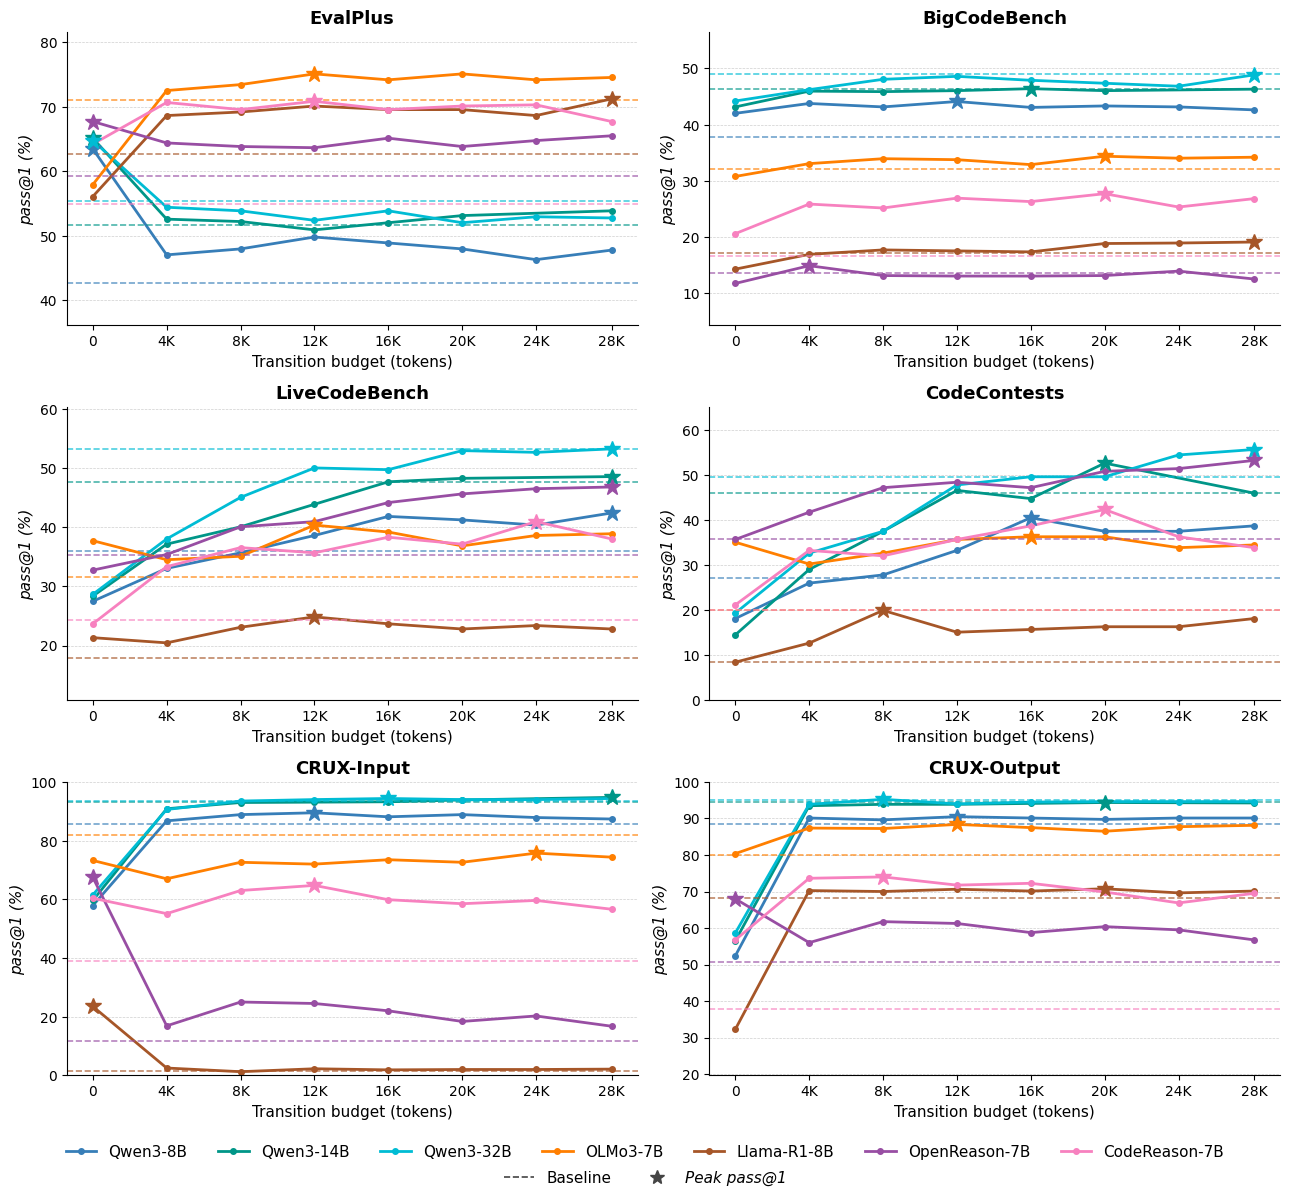

In [71]:
# load data for all models then produce the combined figure
all_model_data = {
    model_name: load_model_data(model_key) for model_name, model_key in MODELS.items()
}

plot_all_models_per_benchmark(
    all_model_data=all_model_data,
    save_path=FIGURES_DIR / "04_transition.png",
)

In [72]:
# # 3-column (2-row) variant — same width and font sizes, y-label on left column only
# plot_all_models_per_benchmark(
#     all_model_data=all_model_data,
#     save_path=FIGURES_DIR / "04_transition_3col.png",
#     n_cols=3,
#     left_ylabel_only=True,
# )